In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

import numpy as np 
import tensorflow as tf 
from tensorflow.keras import * 

from tensorflow.keras.layers import * 
from tensorflow.keras.models import load_model, save_model 
from tensorflow.keras import Model
import tensorflow.keras.utils as utils
from keras.datasets import mnist 

#from includes.fully_connected_opt_weight_generation import * 

### Original Floating-point Model 

In [2]:
def Net(): 
    # inputs = Input(shape=x_train.shape[1:])
    inputs = Input(shape=(28, 28, 1))
    x = Flatten()(inputs)
    x = Dense(100)(x)
    x = ReLU()(x)
    x = Dense(100)(x)
    x = ReLU()(x)
    x = Dense(100)(x)
    x = ReLU()(x)
    x = Dense(10)(x)
    predictions = Softmax()(x)
    return Model(inputs=inputs, outputs=predictions)

In [3]:
epochs = 5 
num_classes = 10 
(x_train, y_train_num), (x_test, y_test_num) = mnist.load_data() 
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
y_train = utils.to_categorical(y_train_num, num_classes)
y_test = utils.to_categorical(y_test_num, num_classes)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

model = Net()
model.load_weights('neural_network_model.h5')

(60000, 28, 28, 1) (10000, 28, 28, 1) (60000, 10) (10000, 10)


In [4]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28, 1)]       0         
_________________________________________________________________
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 100)               78500     
_________________________________________________________________
re_lu (ReLU)                 (None, 100)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 100)               10100     
_________________________________________________________________
re_lu_1 (ReLU)               (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 100)               10100 

In [5]:
length = y_test.shape[0]
positives = 0
res = 0 
for i in range(length): 
    pred = model(x_test[i:i+1]).numpy().squeeze()
    y_test = (y_test > 0.5)
    pred_cast = (pred > 0.5)
    if i == 200: 
        print("y_test   :", y_test[i])
        print("pred     :", pred)
        print("pred_cast:", pred_cast)
        print("res    :", y_test[i]==pred)
        print('\n')

    positives = np.sum(y_test[i] == pred)
    if positives == 10: 
        res += 1
print("Res:", res)
print("length:", length)
print("Accuracy:", res/length)

y_test   : [False False False  True False False False False False False]
pred     : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
pred_cast: [False False False  True False False False False False False]
res    : [ True  True  True  True  True  True  True  True  True  True]


Res: 9672
length: 10000
Accuracy: 0.9672


In [6]:
"""
quantize numpy array
return:
x_q: quantized array
x_fp: reverse quantized array to float
"""
def quantize_array(x, bit_depth=8):
    min_x = x.min() 
    max_x = x.max()

    #find number of integer bits to represent this range
    int_bits = int(np.ceil(np.log2(max(abs(min_x),abs(max_x)))))
    
    if int_bits < 0: int_bits = 0

    frac_bits = bit_depth - 1 - int_bits #remaining bits are fractional bits (1-bit for sign)

    #floating point weights are scaled and rounded to [-2^(bit-1),2^(bit-1)-1], which are used in 
    #the fixed-point operations on the actual hardware (i.e., microcontroller)
    x_q = np.round(x*(2**frac_bits))

    # To quantify the impact of quantized weights, scale them back to
    # original range to run inference using quantized weights
    x_fp = x_q/(2**frac_bits)
    
    return x_q, x_fp, int_bits, frac_bits


"""
compute frac_bits based on max and min list
used for activation(feature map) quantization
"""
def min_max_quantize(max_list, min_list, bit_depth=8):
    frac_list = []
    for i in range(len(max_list)):
        int_bits = int(np.ceil(np.log2(max(abs(min_list[i]),abs(max_list[i])))))

        if int_bits < 0: int_bits = 0
        frac_bits = bit_depth - 1 - int_bits #remaining bits are fractional bits (1-bit for sign)
        frac_list.append(frac_bits)
    return frac_list

### Quantized Model

In [7]:
def QNet(bit=32, shift_list=[]):
    shift = False 
    if bit != 32: 
        shift = True 
    # input shape = (28, 28, 1)
    input = Input(shape=x_train.shape[1:], name='input')
    x = Flatten(name='flatten')(input)
    x = Dense(100, name='fc1')(x)
    if shift:
        x = x / 2**shift_list[0]
        x = tf.floor(x)
        x = tf.clip_by_value(x, -2**(bit-1), 2**(bit-1)-1)
    x = ReLU(name='relu1')(x)

    x = Dense(100, name='fc2')(x)
    if shift:
        x = x / 2**shift_list[1]
        x = tf.floor(x)
        x = tf.clip_by_value(x, -2**(bit-1), 2**(bit-1)-1)
    x = ReLU(name='relu2')(x)
    
    x = Dense(100, name='fc3')(x)
    if shift:
        x = x / 2**shift_list[2]
        x = tf.floor(x)
        x = tf.clip_by_value(x, -2**(bit-1), 2**(bit-1)-1)
    x = ReLU(name='relu3')(x)


    x = Dense(10, name='fc4')(x)
    if shift: 
        x = x / 2**shift_list[3]
        x = tf.floor(x)
        x = tf.clip_by_value(x, -2**(bit-1), 2**(bit-1)-1)
    else:
        x_out = x
    x_out = Softmax(name='softmax')(x)
    return Model(input, x_out)


# To check if the layer name went in correctly
model = QNet()
model.load_weights('neural_network_model.h5')
layer_names = [] 
complete_layers_name = [] 

for layer in model.layers: 
    if len(layer.get_weights()) != 0:
        layer_names.append(layer.name)
    complete_layers_name.append(layer.name)

complete_layers_name.remove('input')

layer_num = len(layer_names)
complete_layer_num = len(complete_layers_name)
print("Layer (With Weights) Names: ", layer_names)
print("TOTAL Layer Names: ", complete_layers_name)

Layer (With Weights) Names:  ['fc1', 'fc2', 'fc3', 'fc4']
TOTAL Layer Names:  ['flatten', 'fc1', 'relu1', 'fc2', 'relu2', 'fc3', 'relu3', 'fc4', 'softmax']


In [8]:
"""
 intermediate feature map retrieval 
 for max and min value acquisition and computing quantization format
"""
intermediate_output = [model.get_layer('input').output]
print("Intermediate Output::", intermediate_output)

for i in range(layer_num):
    intermediate_output.append(model.get_layer(layer_names[i]).output)
print("Intermediate Output::", intermediate_output)
# intermediate output of input and other weighted layers are stored in a list

intermediate_layer_model = Model(inputs=model.input, outputs=intermediate_output)
print(intermediate_layer_model)
print(intermediate_output)
print('\n')
#-------------------------------

# Get output from all layers
complete_intermediate_output = []
for i in range(complete_layer_num):
    complete_intermediate_output.append(model.get_layer(complete_layers_name[i]).output)
print("Complete Intermediate Output::", complete_intermediate_output)

complete_intermediate_layer_model = Model(inputs=model.input, outputs=complete_intermediate_output)
print(complete_intermediate_layer_model)

Intermediate Output:: [<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input')>]
Intermediate Output:: [<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc1')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc2')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc3')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'fc4')>]
[<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc1')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc2')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc3')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'fc4')>]


Complete Intermediate Output:: [<KerasTensor: shape=(None, 784) dtype=float32 (created by layer 'flatten')>, <KerasTensor: sha

In [9]:
print(x_test[1].shape)
print(x_test[10:11].shape)

(28, 28, 1)
(1, 28, 28, 1)


In [10]:
"""
Extract the maximum and minimum value for 
the output of each layer specified in the previous cell
"""
frac_bits_output_list = [] 
max_list = []
min_list = [] 
for i in range(length):
    pred = intermediate_layer_model(x_test[i:i+1])
    for i in range(len(pred)):
        pred_np = pred[i].numpy()
        max_np = pred_np.max()
        min_np = pred_np.min()
        if len(max_list) != len(pred):
            max_list.append(max_np)
            min_list.append(min_np)
        else:
            if max_np > max_list[i]:
                max_list[i] = max_np
            if min_np < min_list[i]:
                min_list[i] = min_np

print("Max list::", max_list)
print("Min list::", min_list)
print()

bit_depth = 16
frac_bits_activation_list = min_max_quantize(max_list, min_list, bit_depth=bit_depth)

print("input: ", frac_bits_activation_list)
for i in range(layer_num):
    print(i+1, " ", layer_names[i], " ", frac_bits_activation_list[i+1])

Max list:: [255.0, 2206.0947, 2183.19, 2972.435, 6425.7407]
Min list:: [0.0, -3684.5205, -2232.9084, -2937.5159, -5925.8926]

input:  [7, 3, 3, 3, 2]
1   fc1   3
2   fc2   3
3   fc3   3
4   fc4   2


### Quantization (16 bits)


In [12]:
frac_bits_weight_list = [] 
frac_bits_bias_list = [] 
q_weight_list = [] 
q_bias_list = [] 

for i in range(layer_num):
    weight, bias = model.get_layer(layer_names[i]).get_weights()
    q_weight, f_weight, int_bits_weight, frac_bits_weight = quantize_array(weight, bit_depth=bit_depth)
    q_bias, f_bias, int_bits_bias, frac_bits_bias = quantize_array(bias, bit_depth=bit_depth)
    
    q_weight_list.append(q_weight)
    q_bias_list.append(q_bias)
    frac_bits_weight_list.append(frac_bits_weight)
    frac_bits_bias_list.append(frac_bits_bias)
    print('***********')
    print(layer_names[i] + '-- weight -- Q' + str(int_bits_weight) + '.' + str(frac_bits_weight))
    print(layer_names[i] + '-- bias -- Q' + str(int_bits_bias) + '.' + str(frac_bits_bias))    


for i in range (layer_num):
    weight, bias = model.get_layer(layer_names[i]).get_weights() 
    print(weight.shape)
    print(weight)


***********
fc1-- weight -- Q0.15
fc1-- bias -- Q0.15
***********
fc2-- weight -- Q0.15
fc2-- bias -- Q0.15
***********
fc3-- weight -- Q0.15
fc3-- bias -- Q0.15
***********
fc4-- weight -- Q0.15
fc4-- bias -- Q0.15
(784, 100)
[[ 0.00487572  0.04587498  0.04863092 ... -0.02218423  0.04506306
  -0.03261687]
 [-0.01491813  0.06300651  0.05276661 ... -0.0628619  -0.04412153
   0.07624668]
 [ 0.01976712  0.06759813  0.07208844 ... -0.03412681 -0.07684609
  -0.08049391]
 ...
 [ 0.02974542 -0.0389428   0.0712321  ...  0.06509919 -0.01272212
   0.0155996 ]
 [-0.04590793 -0.05038456 -0.04948502 ... -0.04836992  0.05767258
   0.02070696]
 [-0.04783644  0.07791334  0.06981987 ...  0.00149608 -0.01015076
  -0.05733009]]
(100, 100)
[[-0.04407237  0.04690942 -0.16413112 ...  0.23212644  0.17555009
  -0.06727734]
 [ 0.16069514 -0.38380572  0.29656017 ... -0.19595647 -0.36367792
   0.18147273]
 [-0.19984214  0.08995983 -0.28337598 ...  0.09113061  0.27015713
   0.07356131]
 ...
 [ 0.12161869  0.05973

In [13]:
# computing bias shift-left and output shift-right
bias_shift_list = np.array(frac_bits_weight_list) + np.array(frac_bits_activation_list[0:-1]) - np.array(frac_bits_bias_list)
output_shift_list = np.array(frac_bits_weight_list) + np.array(frac_bits_activation_list[0:-1]) - np.array(frac_bits_activation_list[1:])  
print(bias_shift_list)
print(output_shift_list)

[7 3 3 3]
[19 15 15 16]


In [14]:
q_model = QNet(bit=bit_depth, shift_list=output_shift_list)

for i in range(layer_num):
    q_model.get_layer(layer_names[i]).set_weights([q_weight_list[i], q_bias_list[i] * (2**bias_shift_list[i])])

# evaluation 
length = y_test.shape[0]
positives = 0
for i in range(length):
    pred = q_model(np.round(x_test[i:i+1]*(2**frac_bits_activation_list[0])))
    pred_cast = pred > 0.5

    if i == 0 or i == 5 or i == 10:
        print("y_test   :", y_test[i])
        print("pred     :", pred)
        print("pred_cast:", pred_cast)
        print("res    :", y_test[i]==pred_cast)
        print('\n')
    positives += np.sum(y_test[i] == pred_cast)
    if positives == 10:
        res += 1
    
print("Accuracy after quantization: ", res / length)

y_test   : [False False False False False False False  True False False]
pred     : tf.Tensor(
[[2.5436657e-13 2.0611535e-09 5.6027964e-09 5.6027964e-09 3.7751347e-11
  5.1090889e-12 8.5330483e-17 1.0000000e+00 2.7894681e-10 1.5229981e-08]], shape=(1, 10), dtype=float32)
pred_cast: tf.Tensor([[False False False False False False False  True False False]], shape=(1, 10), dtype=bool)
res    : tf.Tensor([[ True  True  True  True  True  True  True  True  True  True]], shape=(1, 10), dtype=bool)


y_test   : [False  True False False False False False False False False]
pred     : tf.Tensor(
[[7.1993389e-10 5.8336850e-06 2.3534766e-03 4.7270838e-02 2.4151094e-13
  8.6579565e-04 1.9569832e-09 4.3105429e-05 9.4946021e-01 7.8950342e-07]], shape=(1, 10), dtype=float32)
pred_cast: tf.Tensor([[False False False False False False False False  True False]], shape=(1, 10), dtype=bool)
res    : tf.Tensor([[ True False  True  True  True  True  True  True False  True]], shape=(1, 10), dtype=bool)


y_te

### Saving quantized weight as .h (Clang) file

In [15]:
"""
Reordering and then saving onto a header file
"""

reordered_weight_list = []
for i in range(len(q_weight_list)):
    # convolution layer
    if len(q_weight_list[i].shape) == 4:
        reordered_weight_list.append(np.moveaxis(q_weight_list[i], 2, 0))
    # dense layer
    else: 
        reordered_weight_list.append(np.moveaxis(q_weight_list[i], 1, 0))

# flatten the weight tensor 
reordered_weight_flatten_list = []
for i in range(len(q_weight_list)): 
    # convolution layer 
    if len(reordered_weight_list[i].shape) == 4:
        reordered_weight_flatten_list.append(reordered_weight_list[i].flatten('F'))
    # dense layer
    else: 
        reordered_weight_flatten_list.append(reordered_weight_list[i].flatten())

# save 
f = open('./quantized_weight.h', 'w')
for i in range(len(q_weight_list)): 
    print('********' + layer_names[i] + '********')
    print('Bias shift: ', bias_shift_list[i])
    print('Output shift: ', output_shift_list[i])
    print('Bias: ', q_bias_list[i].astype(np.int16))
    print('Weight: ', reordered_weight_flatten_list[i].astype(np.int16))
    
    f.write('#define ' + layer_names[i].upper() + '_WT {' + str(reordered_weight_flatten_list[i].astype(np.int16).tolist())[1:-1] + '}\n')
    f.write('#define ' + layer_names[i].upper() + '_BIAS {' + str(q_bias_list[i].astype(np.int16).tolist())[1:-1] + "}\n")
    f.write('#define ' + layer_names[i].upper() + '_BIAS_LSHIFT ' + str(bias_shift_list[i]) + "\n")
    f.write('#define ' + layer_names[i].upper() + '_OUT_RSHIFT ' + str(output_shift_list[i]) + "\n\n")
    
f.close()

********fc1********
Bias shift:  7
Output shift:  19
Bias:  [ 2744  -280  2526  1935  3879  2430  3300  1357  1950 -1782  2227  -605
  -205 -2057  1897  3002   626  3370  3539  -175    27  2038  1961  1809
   838 -1172  2081   143  1049   -27  2089 -1412  1377 -2019  2983  1535
  -222  -699  1235   801  1052  -870  1641 -3705  1506 -1287  -320   158
  3239  1026 -1263  1120   804  1157 -1393 -1522  3588  3210  2256  1583
    -5 -1571  2720  -834   709   702  2089    22 -1500  1220   601 -2025
   225   721  2023  4596 -1223  -497   -91   180  2365  1170   199  1629
 -2007  -878 -3037  -725  -653  -664  1960  1346 -1808   130   -80   542
  2438  3239 -1885  -137]
Weight:  [  160  -489   648 ...   511   679 -1879]
********fc2********
Bias shift:  3
Output shift:  15
Bias:  [-1063  2324 -1732  1511 -1169  -452  -223   516   265 -1794  2294 -1142
  2411  2678  -232 -2404  1153 -1334  1118  1243 -1574  4913  -525  -214
  1384  -662  -414  1314  2292 -1834  2400  3215 -2562  3252 -1263  3973


In [16]:
def convert_to_x4_q15_weights(weights):
    [r, h, w, c] = weights.shape
    weights = np.reshape(weights, (r, h*w*c))
    num_of_rows = r
    num_of_cols = h*w*c
    new_weights = np.copy(weights)
    new_weights = np.reshape(new_weights, (r*h*w*c))
    counter = 0
    for i in range(int(num_of_rows/4)):
      # we only need to do the re-ordering for every 4 rows
      row_base = 4*i
      for j in range(int(num_of_cols/2)):
        # for each 2 entries
        column_base = 2*j
        new_weights[counter]   =  weights[row_base  ][column_base  ]
        new_weights[counter+1] =  weights[row_base  ][column_base+1]
        new_weights[counter+2] =  weights[row_base+1][column_base  ]
        new_weights[counter+3] =  weights[row_base+1][column_base+1]
        new_weights[counter+4] =  weights[row_base+2][column_base  ]
        new_weights[counter+5] =  weights[row_base+2][column_base+1]
        new_weights[counter+6] =  weights[row_base+3][column_base  ]
        new_weights[counter+7] =  weights[row_base+3][column_base+1]

        counter = counter + 8
      # the remaining ones are in order
      for j in range((int)(num_of_cols-num_of_cols%2), int(num_of_cols)):
        new_weights[counter] = weights[row_base][j]
        new_weights[counter+1] = weights[row_base+1][j]
        new_weights[counter+2] = weights[row_base+2][j]
        new_weights[counter+3] = weights[row_base+3][j]
        counter = counter + 4
    return new_weights

In [17]:
opt_weight_list = []

for i in range(layer_num): 
    print(q_weight_list[i].shape)
    input_dim, output_dim = q_weight_list[i].shape
    # move axis  
    tmp = np.moveaxis(q_weight_list[i], 1, 0)
    q_expanded_weight_list = np.reshape(tmp, (output_dim, input_dim, 1, 1))
    reordered_weights = convert_to_x4_q15_weights(q_expanded_weight_list)
    final_weights = np.reshape(reordered_weights, (output_dim, input_dim))
    opt_weight_list.append(reordered_weights)


# flatten the weight tensor 
weight_flatten_list = []
for i in range(len(opt_weight_list)): 
    # convolution layer 
    if len(opt_weight_list[i].shape) == 4:
        weight_flatten_list.append(opt_weight_list[i].flatten('F'))
    # dense layer
    else: 
        weight_flatten_list.append(opt_weight_list[i].flatten())


f = open('./opt_quantized_weight.h', 'w')
for i in range(len(q_weight_list)): 
    print('********' + layer_names[i] + '********')
    print('Bias shift: ', bias_shift_list[i])
    print('Output shift: ', output_shift_list[i])
    print('Bias: ', q_bias_list[i].astype(np.int16))
    print('Weight: ', weight_flatten_list[i].astype(np.int16))
    
    f.write('#define ' + layer_names[i].upper() + '_WT {' + str(weight_flatten_list[i].astype(np.int16).tolist())[1:-1] + '}\n')
    f.write('#define ' + layer_names[i].upper() + '_BIAS {' + str(q_bias_list[i].astype(np.int16).tolist())[1:-1] + "}\n")
    f.write('#define ' + layer_names[i].upper() + '_BIAS_LSHIFT ' + str(bias_shift_list[i]) + "\n")
    f.write('#define ' + layer_names[i].upper() + '_OUT_RSHIFT ' + str(output_shift_list[i]) + "\n\n")
f.close()

(784, 100)
(100, 100)
(100, 100)
(100, 10)
********fc1********
Bias shift:  7
Output shift:  19
Bias:  [ 2744  -280  2526  1935  3879  2430  3300  1357  1950 -1782  2227  -605
  -205 -2057  1897  3002   626  3370  3539  -175    27  2038  1961  1809
   838 -1172  2081   143  1049   -27  2089 -1412  1377 -2019  2983  1535
  -222  -699  1235   801  1052  -870  1641 -3705  1506 -1287  -320   158
  3239  1026 -1263  1120   804  1157 -1393 -1522  3588  3210  2256  1583
    -5 -1571  2720  -834   709   702  2089    22 -1500  1220   601 -2025
   225   721  2023  4596 -1223  -497   -91   180  2365  1170   199  1629
 -2007  -878 -3037  -725  -653  -664  1960  1346 -1808   130   -80   542
  2438  3239 -1885  -137]
Weight:  [  160  -489  1503 ...  -333   679 -1879]
********fc2********
Bias shift:  3
Output shift:  15
Bias:  [-1063  2324 -1732  1511 -1169  -452  -223   516   265 -1794  2294 -1142
  2411  2678  -232 -2404  1153 -1334  1118  1243 -1574  4913  -525  -214
  1384  -662  -414  1314  2292

### Saving Intermediate Output Data of the Neural Network 

In [39]:
intermediate_output = []
intermediate_output.append(q_model.get_layer('input').output)

for i in range(layer_num):
    intermediate_output.append(q_model.get_layer(layer_names[i]).output)

q_intermediate_layer_model = Model(inputs=q_model.input, outputs=intermediate_output)
sample_output = q_intermediate_layer_model.predict(np.round(x_test[0:1]*(2**frac_bits_activation_list[0])))

# save with weight reordering
f = open("./sample_input_output.h", "w")
temp = np.squeeze(sample_output[0], axis=0)
temp = temp.transpose(2, 0, 1)
temp = temp.flatten("F")
f.write("#define " + "INPUT_DATA {" + str(temp.astype(np.int16).tolist())[1:-1] + "}\n")

for i in range(layer_num):
    temp = np.squeeze(sample_output[i+1], axis=0)
    print(temp.shape)
    if len(temp.shape) == 3:
        print(sample_output[i])
        temp = temp.transpose(2, 0, 1)
        temp = temp.flatten("F")
    
    temp = temp.astype(np.int32) >> output_shift_list[i]
    f.write("#define " + layer_names[i].upper() + " {" + str(temp.tolist())[1:-1] + "}\n")

f.close()
print("finished reordering and writing input and output to file")


(100,)
(100,)
(100,)
(10,)
finished reordering and writing input and output to file


### Demonstrating Intermediate Layer Output 
to guide how to deal with dimensional issues in CMSIS 

RAW INPUT
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 128, 128, 0, 128, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 128, 128, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

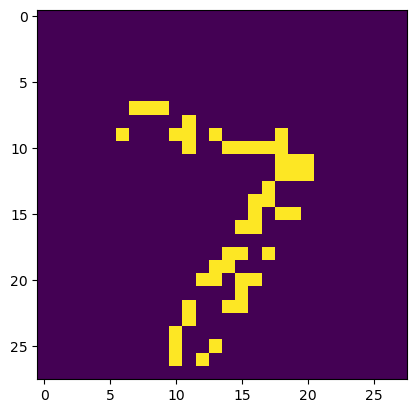

In [40]:
# raw input ------------------------------------------
input_result = []
input_result.append(q_model.get_layer('input').output)
q_intermediate_input = Model(inputs=q_model.input, outputs=input_result)
sample_output = q_intermediate_input.predict(np.round(x_test[0:1]*(2**frac_bits_activation_list[0])))
temp0 = np.squeeze(sample_output, axis=0)
temp = temp0.flatten()
temp = temp.astype(np.int16).tolist()
print("RAW INPUT\n", temp)

plt.imshow(temp0)
print(temp0.shape)

In [41]:
# processed input ----------------------------------------- matches exactly 
input_result = []
input_result.append(q_model.get_layer('input').output)
q_intermediate_input = Model(inputs=q_model.input, outputs=input_result)
sample_output = q_intermediate_input.predict(np.round(x_test[0:1]*(2**frac_bits_activation_list[0])))
temp = np.squeeze(sample_output, axis=0)
temp = temp.transpose(2, 0, 1)
print("AFTER TRANSPOSE\n", temp.astype(np.int16).tolist())

temp = temp.flatten("F")
print("AFTER FLATTEN\n", temp.astype(np.int16).tolist())

temp = temp.astype(np.int16).tolist()
print("FINAL PROCESSED INPUT\n", temp)


AFTER TRANSPOSE
 [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 128, 128, 0, 128, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 128, 128, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0